In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]  # importing functions from other folders
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from _data.data_utils import read_in
# from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64
import re
import pytensor.tensor as pt
from pytensor.gradient import disconnected_grad
from scipy.sparse.linalg import eigsh

az.style.use("arviz-darkgrid")


if '___laptop' in os.listdir('../'):
    # laptop folder
    folder = "../../_data/p-dengue/"
elif '___server' in os.listdir('../'):
    # server folder
    folder = "../../../../../data/lucaratzinger_data/p_dengue/"

%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[smoothness_fixed_p_std]", "a2_201601_201912[smoothness_fixed_p]"]

---

In [134]:
def pareto_k_scatter(model_fits_dir, run_folders, p=None, num_knots=None, std=None):

    data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
    data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
    temp = data['t2m_mean_pop_weighted(0)'].values

    def parse_name(name):
        p_match = re.search(r'p=([\d.]+)', name)
        k_match = re.search(r'__knots\((\d+)', name)
        s_match = re.search(r'std=(True|False)', name)
        return {
            'p': float(p_match.group(1)) if p_match else None,
            'num_knots': int(k_match.group(1)) if k_match else None,
            'std': s_match.group(1) == 'True' if s_match else None,
        }

    def to_set(val):
        if val is None: return None
        return set(val) if hasattr(val, '__iter__') else {val}

    p_set, k_set, std_set = to_set(p), to_set(num_knots), to_set(std)

    matches = []
    for run in run_folders:
        metrics_dir = os.path.join(model_fits_dir, run, 'metrics')
        if not os.path.isdir(metrics_dir):
            continue
        for fname in sorted(os.listdir(metrics_dir)):
            if not fname.endswith('.npz'):
                continue
            meta = parse_name(fname)
            if p_set is not None and meta['p'] not in p_set:
                continue
            if k_set is not None and meta['num_knots'] not in k_set:
                continue
            if std_set is not None and meta['std'] not in std_set:
                continue
            pareto_k = np.load(os.path.join(metrics_dir, fname))['pareto_k']
            matches.append((meta, pareto_k))

    if not matches:
        raise ValueError("No models matched the given filters.")

    colors = cm.tab20(np.linspace(0, 1, len(matches)))
    fig, ax = plt.subplots(figsize=(10, 4))

    for (meta, pareto_k), color in zip(matches, colors):
        label = f"p={meta['p']}, k={meta['num_knots']}, std={meta['std']}"
        ax.scatter(temp, pareto_k, s=0.5, color=color, label=label, alpha=0.6)

    ax.axhline(0.7, color='red', linestyle='--', linewidth=1, label='Pareto k=0.7 threshold (bad)')
    ax.axhline(1.0, color='red', linestyle='-', linewidth=1, label='Pareto k=1.0 threshold (very bad)')
    ax.set_xlabel('t2m_mean_pop_weighted(0)')
    ax.set_ylabel('pareto_k')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=5)

    return fig

In [150]:
import base64
import io

p_vals = [0.1, 0.5, 1.0, 2.0, 3.5, 5.0, 7.0, 10.0, 12.5, 15.0, 20.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80]

html_parts = ['<html><body>']

for p in p_vals:
    fig = pareto_k_scatter(model_fits_folder, run_folders, p=[p], num_knots=num_knots_list, std=[True])
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode('utf-8')
    html_parts.append(f'<h3>p={p}</h3><img src="data:image/png;base64,{b64}"><br>')

html_parts.append('</body></html>')

with open('pareto_k_values_std=True.html', 'w') as f:
    f.write('\n'.join(html_parts))

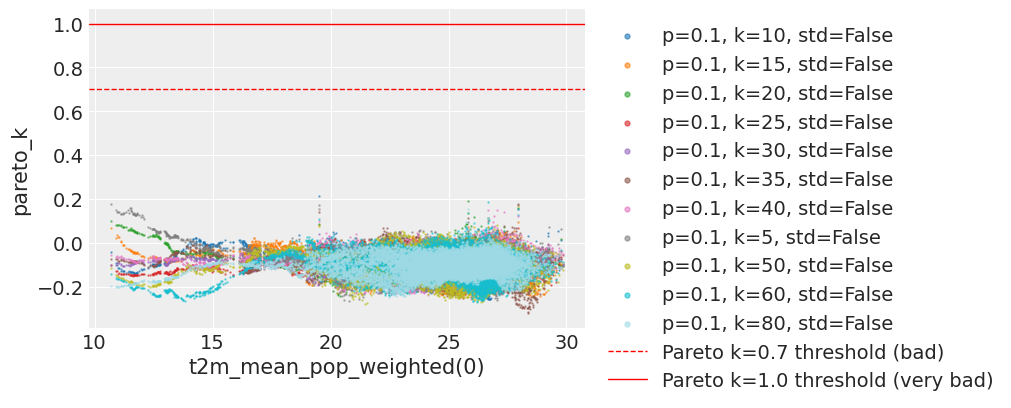

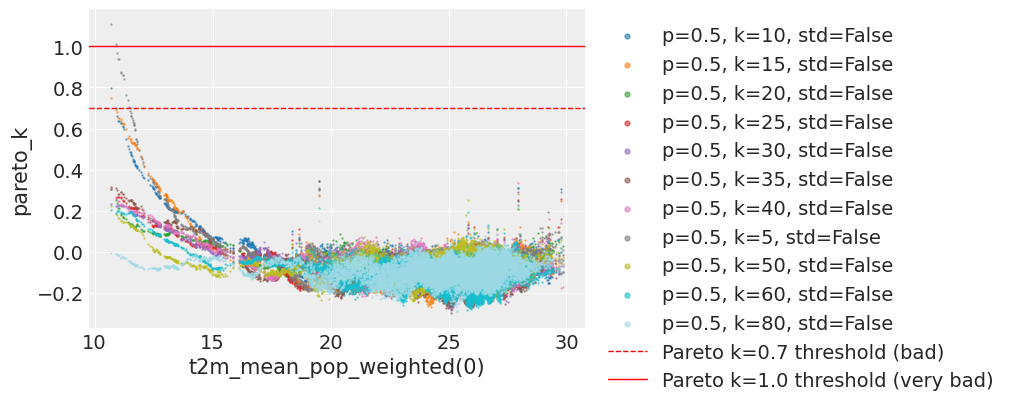

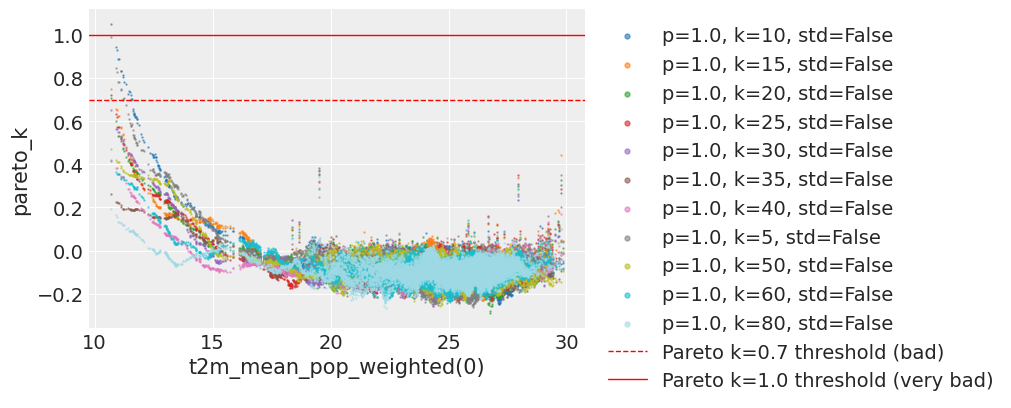

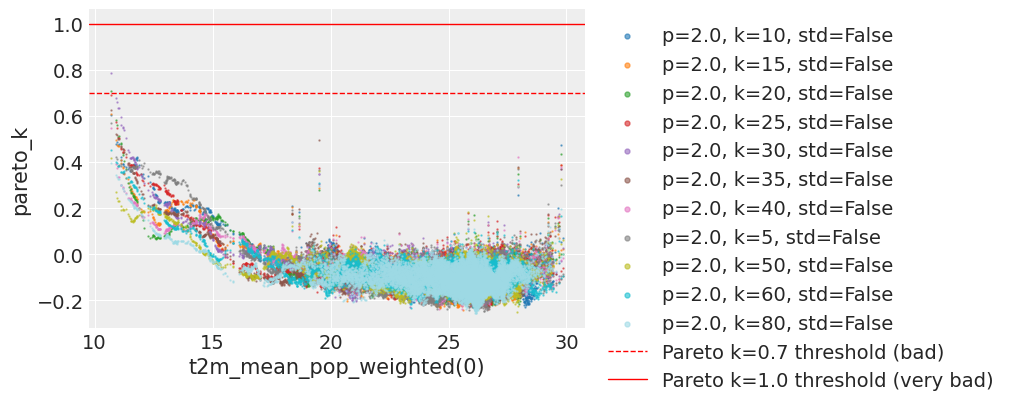

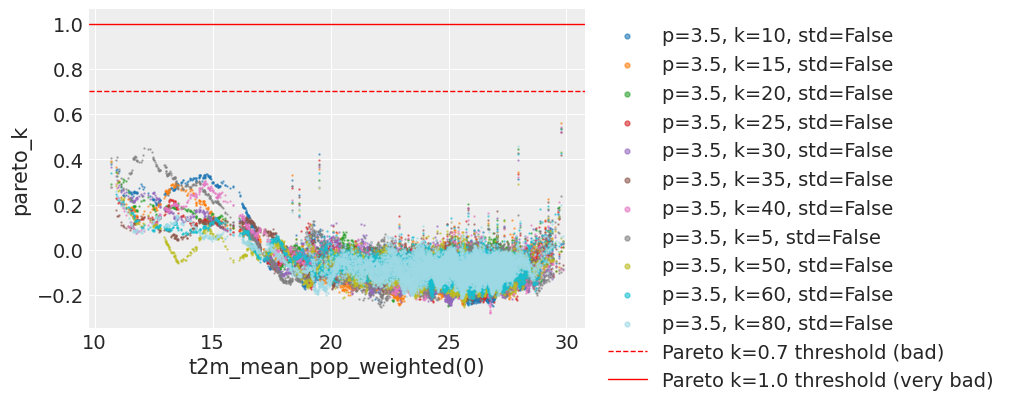

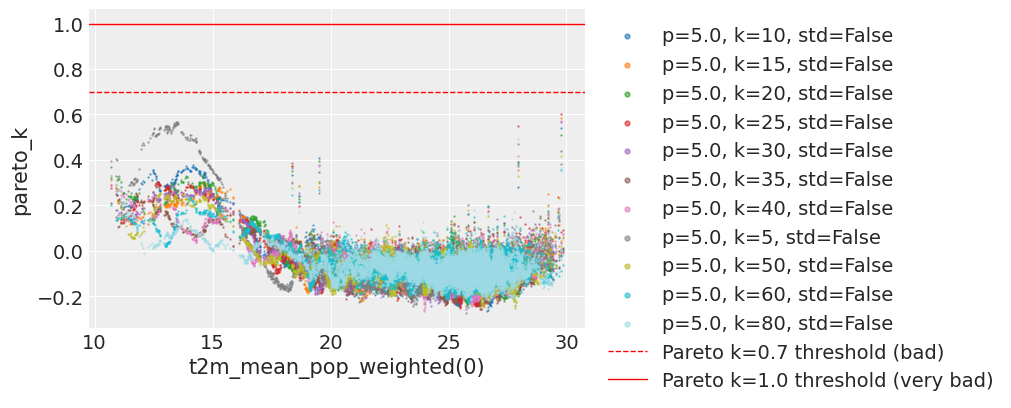

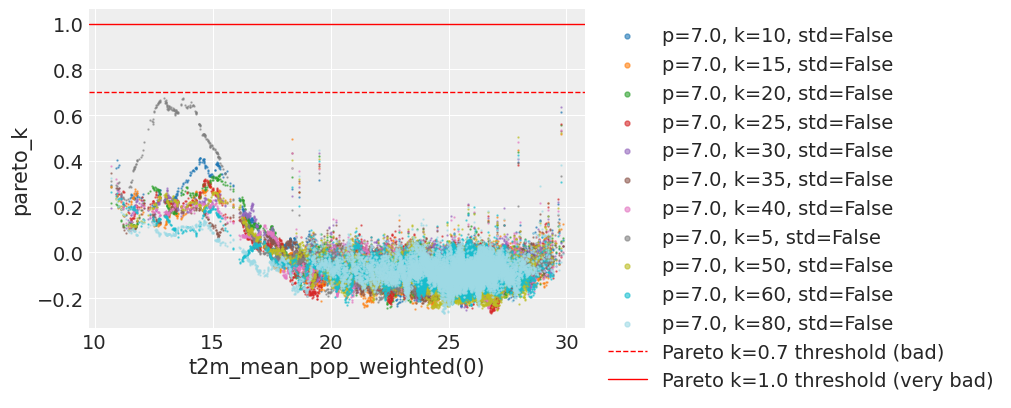

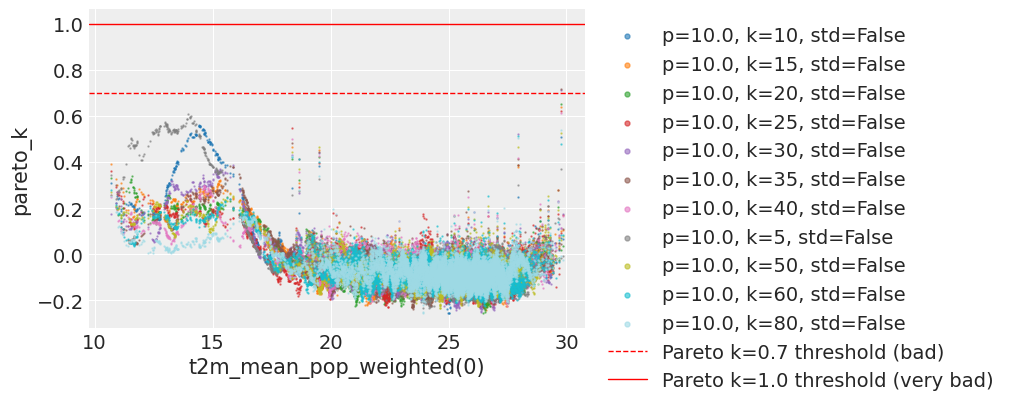

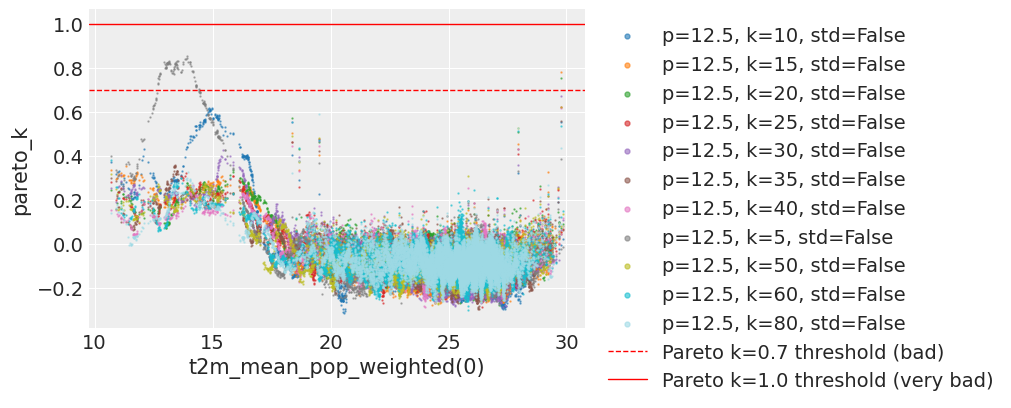

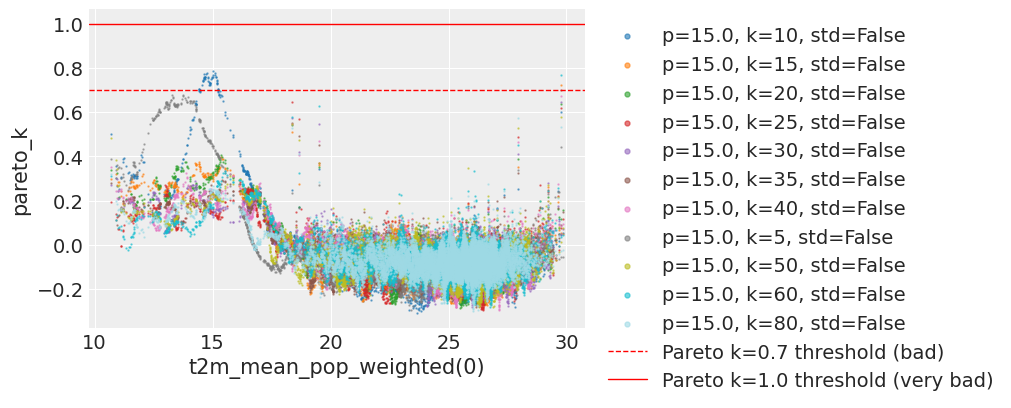

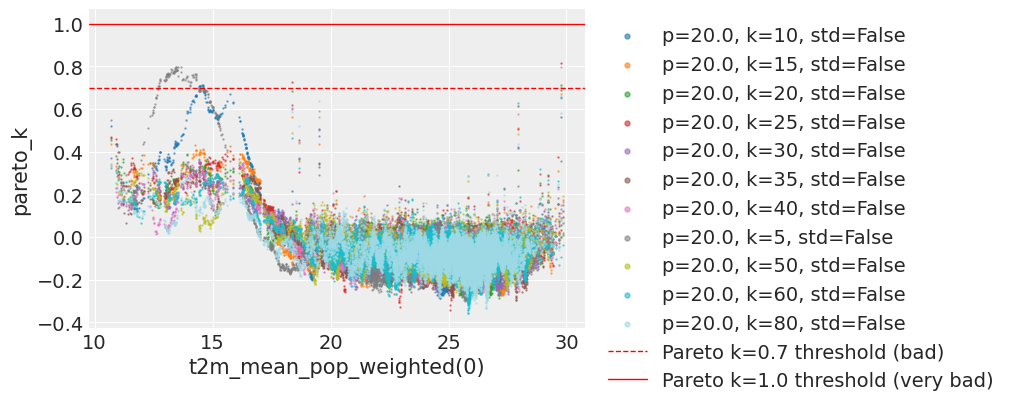

In [ ]:
p_vals = [0.1, 0.5, 1.0, 2.0, 3.5, 5.0, 7.0, 10.0, 12.5, 15.0, 20.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80]
figs = []
for p in p_vals:
    fig = pareto_k_scatter(model_fits_folder, run_folders, p=[p], num_knots=num_knots_list, std=[False])
    figs.append(fig)


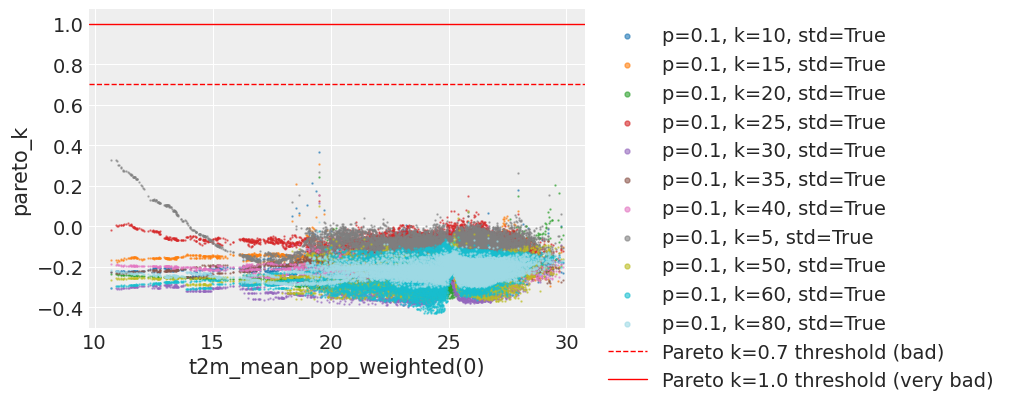

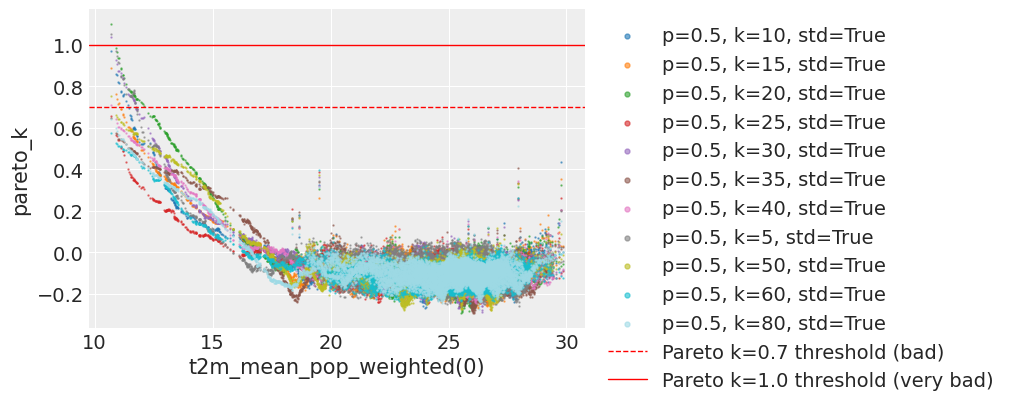

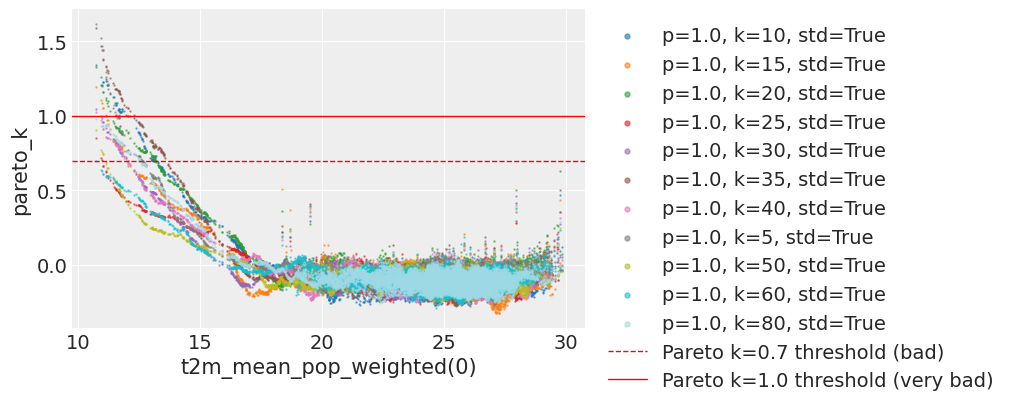

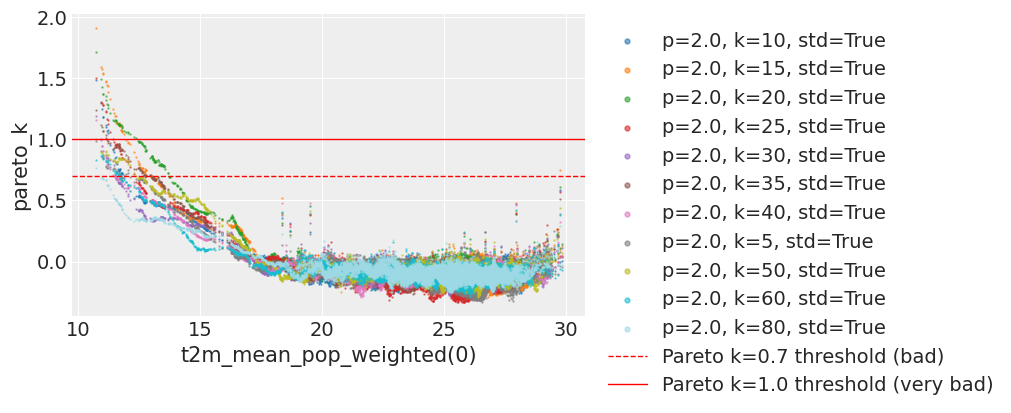

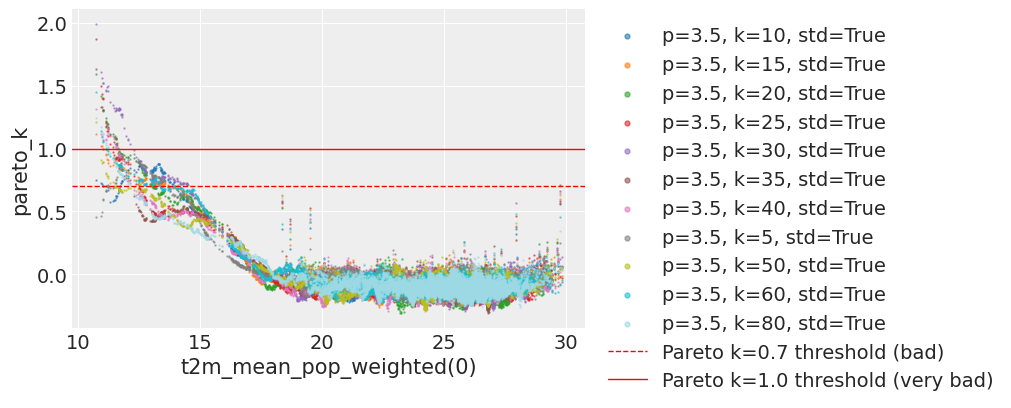

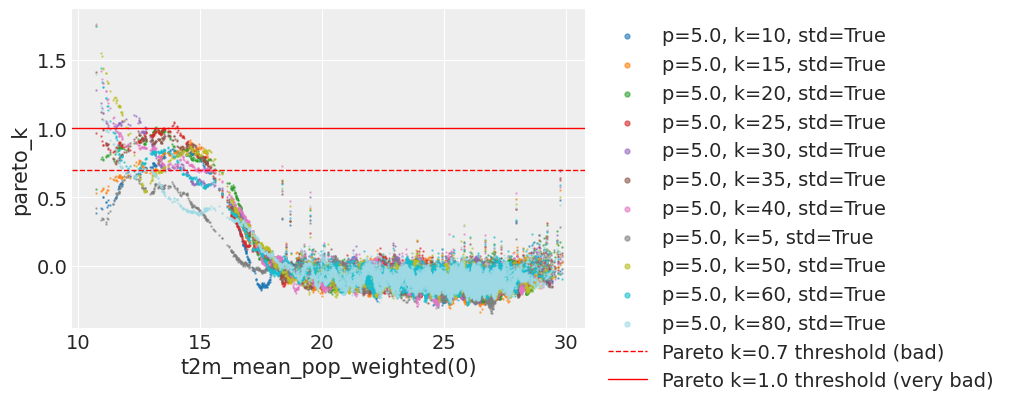

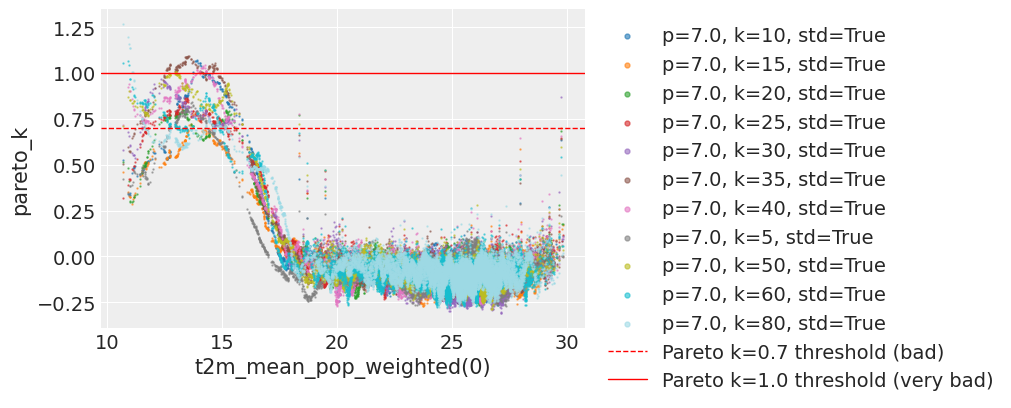

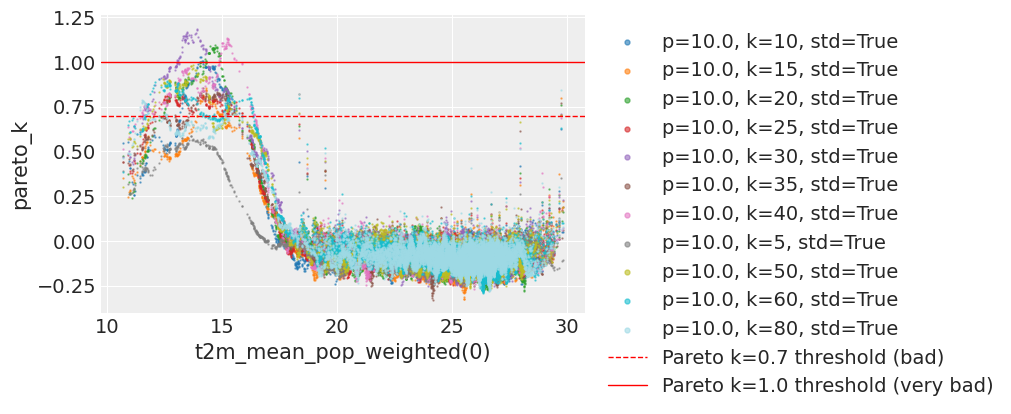

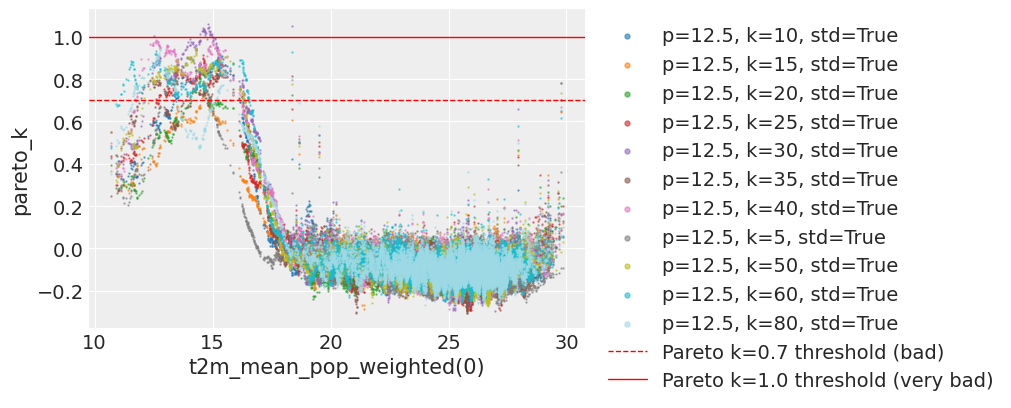

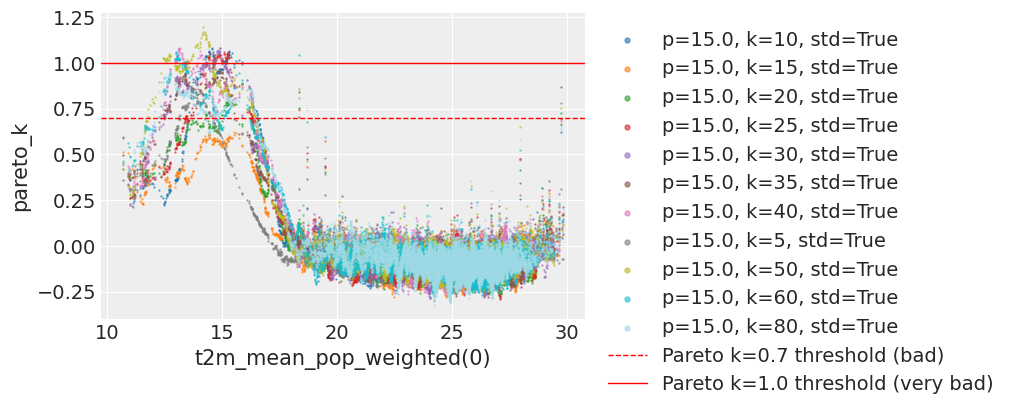

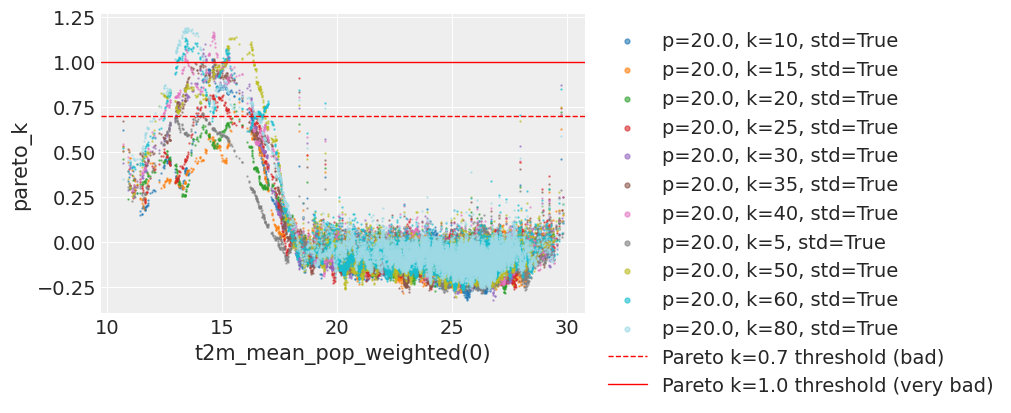

In [136]:
p_vals = [0.1, 0.5, 1.0, 2.0, 3.5, 5.0, 7.0, 10.0, 12.5, 15.0, 20.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80]
for p in p_vals:
    fig = pareto_k_scatter(model_fits_folder, run_folders, p=[p], num_knots=num_knots_list, std=[True])

---

In [19]:
def loo_compare(model_fits_dir, run_folders, p=None, num_knots=None, std=None):
    def parse_name(name):
        p_match = re.search(r'p=([\d.]+)', name)
        k_match = re.search(r'__knots\((\d+)', name)
        s_match = re.search(r'std=(True|False)', name)
        return {
            'p': float(p_match.group(1)) if p_match else None,
            'num_knots': int(k_match.group(1)) if k_match else None,
            'std': s_match.group(1) == 'True' if s_match else None,
        }

    p_set = set(p) if p is not None else None
    k_set = set(num_knots) if num_knots is not None else None
    std_set = set(std) if std is not None else None

    rows = {}
    for run in run_folders:
        metrics_dir = os.path.join(model_fits_dir, run, 'metrics')
        if not os.path.isdir(metrics_dir):
            continue
        for fname in os.listdir(metrics_dir):
            if not fname.endswith('.npz'):
                continue
            meta = parse_name(fname)
            if p_set is not None and meta['p'] not in p_set:
                continue
            if k_set is not None and meta['num_knots'] not in k_set:
                continue
            if std_set is not None and meta['std'] not in std_set:
                continue

            loo_pw = np.load(os.path.join(metrics_dir, fname))['loo_pointwise']
            n = len(loo_pw)
            rows[fname[:-4]] = {
                'elpd_loo': loo_pw.sum(),
                'se': (n * loo_pw.var()) ** 0.5,
                'pointwise': loo_pw,
            }

    if not rows:
        raise ValueError("No models matched the given filters.")
    
    df = pd.DataFrame(rows).T.sort_values('elpd_loo', ascending=False)
    best_pw = df['pointwise'].iloc[0]
    elpd_diff, dse = [], []
    for pw in df['pointwise']:
        diff_pw = best_pw - pw
        elpd_diff.append(diff_pw.sum())
        dse.append(np.std(diff_pw) * np.sqrt(len(diff_pw)))
    
    df['elpd_diff'] = elpd_diff
    df['dse'] = dse
    df = df.drop(columns='pointwise')
    return df

In [117]:
def loo_compare_idata(model_fits_dir, run_folders, p=None, num_knots=None, std=None):
    def parse_name(name):
        p_match = re.search(r'p=([\d.]+)', name)
        k_match = re.search(r'__knots\((\d+)', name)
        s_match = re.search(r'std=(True|False)', name)
        return {
            'p': float(p_match.group(1)) if p_match else None,
            'num_knots': int(k_match.group(1)) if k_match else None,
            'std': s_match.group(1) == 'True' if s_match else None,
        }

    def to_set(val):
        if val is None: return None
        return set(val) if hasattr(val, '__iter__') else {val}

    p_set, k_set, std_set = to_set(p), to_set(num_knots), to_set(std)

    idata_dict = {}
    for run in run_folders:
        idata_dir = os.path.join(model_fits_dir, run, 'idata')
        if not os.path.isdir(idata_dir):
            continue
        for fname in os.listdir(idata_dir):
            if not fname.endswith('.nc'):
                continue
            meta = parse_name(fname)
            if p_set is not None and meta['p'] not in p_set:
                continue
            if k_set is not None and meta['num_knots'] not in k_set:
                continue
            if std_set is not None and meta['std'] not in std_set:
                continue

            idata_dict[fname[:-3]] = az.from_netcdf(os.path.join(idata_dir, fname))

    if not idata_dict:
        raise ValueError("No models matched the given filters.")

    return az.compare(idata_dict)

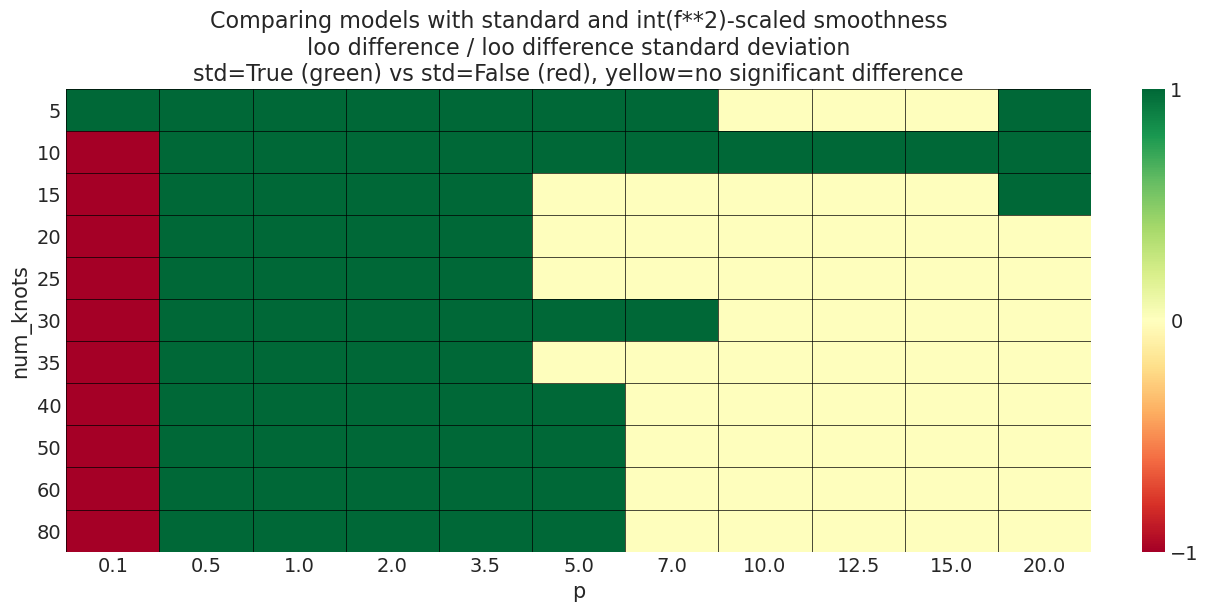

In [137]:
n_se = 1  # number of standard errors for significance threshold

p_vals = [0.1, 0.5, 1.0, 2.0, 3.5, 5.0, 7.0, 10.0, 12.5, 15.0, 20.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80]

records = []
for p_val in p_vals:
    for nk in num_knots_list:
        df = loo_compare(model_fits_folder, run_folders, p=[p_val], num_knots=[nk], std=[True, False])
        if len(df) < 2:
            continue
        df['std'] = df.index.str.extract(r'std=(True|False)', expand=False)
        
        true_row = df[df['std'] == 'True']
        false_row = df[df['std'] == 'False']
        if true_row.empty or false_row.empty:
            continue
        
        elpd_diff = true_row['elpd_loo'].values[0] - false_row['elpd_loo'].values[0]
        dse = df['dse'].values[-1]

        if abs(elpd_diff) < n_se * dse:
            winner = 0
        elif elpd_diff > 0:
            winner = n_se   # std=True is better
        else:
            winner = -n_se  # std=False is better

        records.append({'p': p_val, 'num_knots': nk, 'std_better': winner, 'elpd_diff': elpd_diff, 'se': dse})

results_df = pd.DataFrame(records)
#print(results_df)
pivot = results_df.pivot(index='num_knots', columns='p', values='std_better')

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.RdYlGn  # red=-1, yellow=0, green=1
im = ax.imshow(pivot.values, cmap=cmap, vmin=-n_se, vmax=n_se, aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# minor ticks for grid lines only
ax.set_xticks(np.arange(-0.5, len(pivot.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(pivot.index), 1), minor=True)
ax.grid(which='minor', color='black', linewidth=0.5)
ax.tick_params(which='minor', length=0)
ax.grid(which='major', visible=False)  # remove the default major grid

ax.set_xlabel('p')
ax.set_ylabel('num_knots')
ax.set_title('Comparing models with standard and int(f**2)-scaled smoothness\nloo difference / loo difference standard deviation\nstd=True (green) vs std=False (red), yellow=no significant difference')

plt.colorbar(im, ax=ax, ticks=[-n_se, 0, n_se])
plt.show()

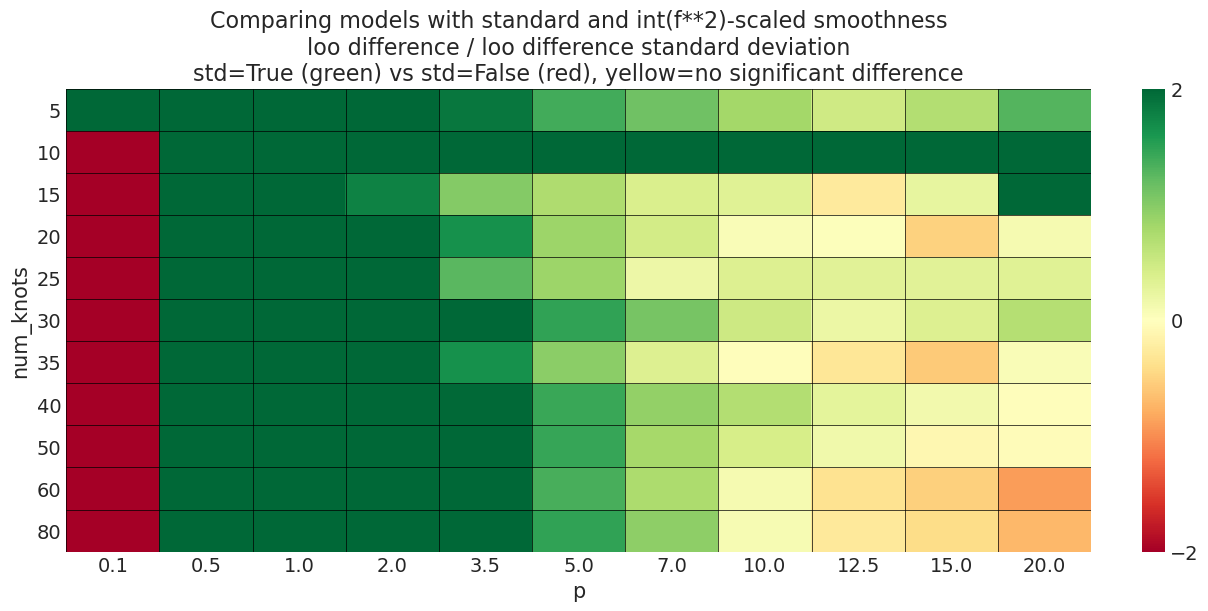

In [108]:
n_se = 2  # number of standard errors for significance threshold

p_vals = [0.1, 0.5, 1.0, 2.0, 3.5, 5.0, 7.0, 10.0, 12.5, 15.0, 20.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80]

records = []
for p_val in p_vals:
    for nk in num_knots_list:
        df = loo_compare(model_fits_folder, run_folders, p=[p_val], num_knots=[nk], std=[True, False])
        if len(df) < 2:
            continue
        df['std'] = df.index.str.extract(r'std=(True|False)', expand=False)
        
        true_row = df[df['std'] == 'True']
        false_row = df[df['std'] == 'False']
        if true_row.empty or false_row.empty:
            continue
        
        elpd_diff = true_row['elpd_loo'].values[0] - false_row['elpd_loo'].values[0]
        dse = df['dse'].values[-1]

        winner = elpd_diff / dse if dse > 0 else 0  # use standardized difference as winner metric

        records.append({'p': p_val, 'num_knots': nk, 'std_better': winner, 'elpd_diff': elpd_diff, 'se': dse})

results_df = pd.DataFrame(records)
#print(results_df)
pivot = results_df.pivot(index='num_knots', columns='p', values='std_better')

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.RdYlGn  # red=-1, yellow=0, green=1
im = ax.imshow(pivot.values, cmap=cmap, vmin=-n_se, vmax=n_se, aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# minor ticks for grid lines only
ax.set_xticks(np.arange(-0.5, len(pivot.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(pivot.index), 1), minor=True)
ax.grid(which='minor', color='black', linewidth=0.5)
ax.tick_params(which='minor', length=0)
ax.grid(which='major', visible=False)  # remove the default major grid

ax.set_xlabel('p')
ax.set_ylabel('num_knots')
ax.set_title('Comparing models with standard and int(f**2)-scaled smoothness\nloo difference / loo difference standard deviation\nstd=True (green) vs std=False (red), yellow=no significant difference')

plt.colorbar(im, ax=ax, ticks=[-n_se, 0, n_se])
plt.show()

---

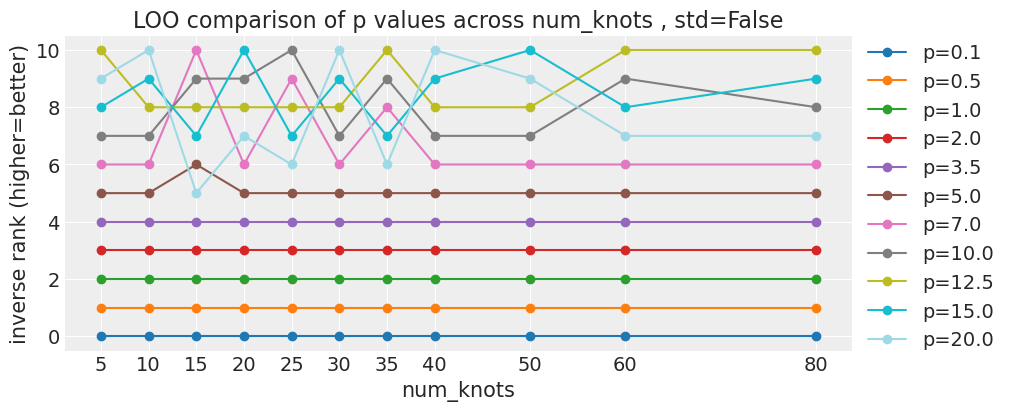

In [38]:
p_vals = [0.1, 0.5, 1.0, 2.0, 3.5, 5.0, 7.0, 10.0, 12.5, 15.0, 20.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80]

colors = cm.tab20(np.linspace(0, 1, len(p_vals)))
fig, ax = plt.subplots(figsize=(10, 4))

for p_val, color in zip(p_vals, colors):
    ranks = []
    for nk in num_knots_list:
        df = loo_compare(model_fits_folder, run_folders, p=p_vals, num_knots=[nk], std=[False])
        df['p'] = df.index.str.extract(r'p=([\d.]+)', expand=False).astype(float)
        df['inv_rank'] = len(df) - 1 - np.array(range(len(df)))
        row = df[df['p'] == p_val]
        ranks.append(row['inv_rank'].values[0] if len(row) else np.nan)
    ax.plot(num_knots_list, ranks, marker='o', label=f'p={p_val}', color=color)

ax.set_title("LOO comparison of p values across num_knots , std=False")
ax.set_xlabel('num_knots')
ax.set_ylabel('inverse rank (higher=better)')
ax.set_xticks(num_knots_list)
ax.set_xticklabels(num_knots_list)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.show()

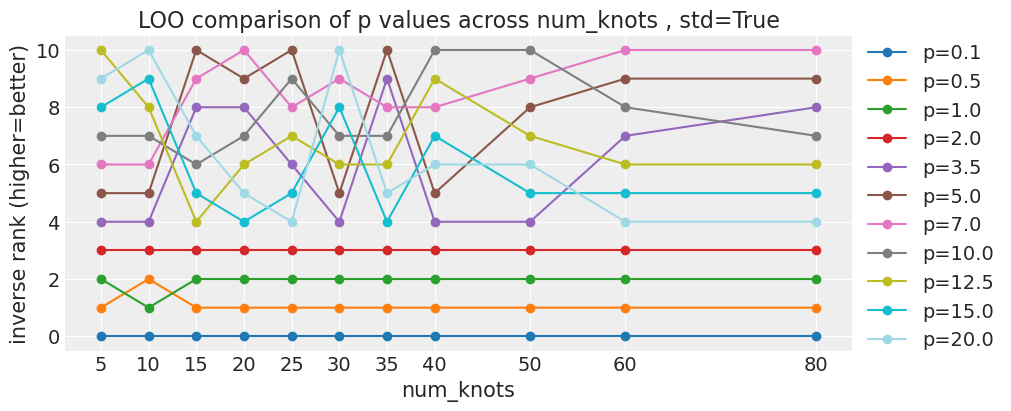

In [37]:
p_vals = [0.1, 0.5, 1.0, 2.0, 3.5, 5.0, 7.0, 10.0, 12.5, 15.0, 20.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80]

colors = cm.tab20(np.linspace(0, 1, len(p_vals)))
fig, ax = plt.subplots(figsize=(10, 4))

for p_val, color in zip(p_vals, colors):
    ranks = []
    for nk in num_knots_list:
        df = loo_compare(model_fits_folder, run_folders, p=p_vals, num_knots=[nk], std=[True])
        df['p'] = df.index.str.extract(r'p=([\d.]+)', expand=False).astype(float)
        df['inv_rank'] = len(df) - 1 - np.array(range(len(df)))
        row = df[df['p'] == p_val]
        ranks.append(row['inv_rank'].values[0] if len(row) else np.nan)
    ax.plot(num_knots_list, ranks, marker='o', label=f'p={p_val}', color=color)

ax.set_title("LOO comparison of p values across num_knots , std=True")
ax.set_xlabel('num_knots')
ax.set_ylabel('inverse rank (higher=better)')
ax.set_xticks(num_knots_list)
ax.set_xticklabels(num_knots_list)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.show()

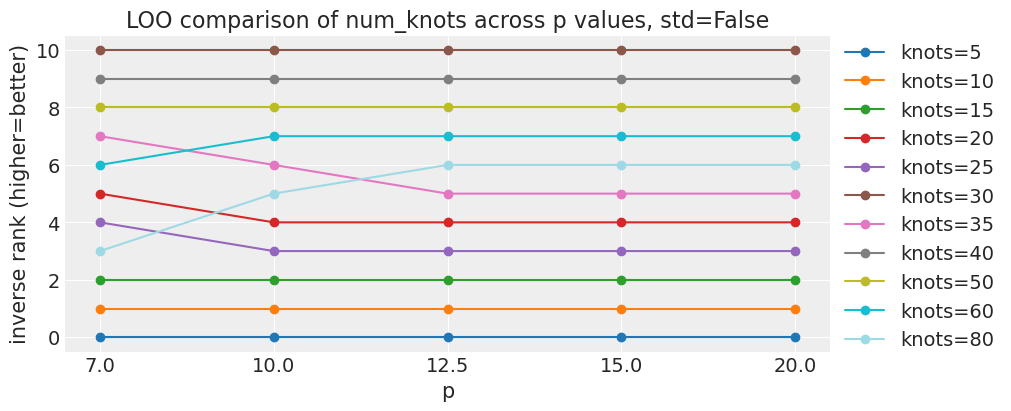

In [111]:
p_vals = [7.0, 10.0, 12.5, 15.0, 20.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80]

colors = cm.tab20(np.linspace(0, 1, len(num_knots_list)))
fig, ax = plt.subplots(figsize=(10, 4))

for nk, color in zip(num_knots_list, colors):
    ranks = []
    for p_val in p_vals:
        df = loo_compare(model_fits_folder, run_folders, p=[p_val], num_knots=None, std=[False])
        df['num_knots'] = df.index.str.extract(r'__knots\((\d+)', expand=False).astype(int)
        df['inv_rank'] = len(df) - 1 - np.array(range(len(df)))
        row = df[df['num_knots'] == nk]
        ranks.append(row['inv_rank'].values[0] if len(row) else np.nan)
    ax.plot(np.arange(len(p_vals)), ranks, marker='o', label=f'knots={nk}', color=color)

ax.set_title("LOO comparison of num_knots across p values, std=False")
ax.set_xlabel('p')
ax.set_ylabel('inverse rank (higher=better)')
ax.set_xticks(np.arange(len(p_vals)))
ax.set_xticklabels(p_vals)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.show()

In [148]:
df_compare = loo_compare(model_fits_folder, run_folders, p=[7.0, 10.0, 12.5, 15.0, 20.0], num_knots=[25, 30, 35, 40, 50, 60], std=[False])
df_compare['p'] = df_compare.index.str.extract(r'p=([\d.]+)', expand=False).astype(float)
df_compare['num_knots'] = df_compare.index.str.extract(r'__knots\((\d+)', expand=False).astype(int)
df_compare.reset_index(inplace=True, drop=True)
df_compare = df_compare[['p', 'num_knots', 'elpd_loo', 'dse', 'elpd_diff']]
display(df_compare)
df_compare.to_csv("best_p_num_knots_loo_comparison.csv", index=False)

,p,num_knots,elpd_loo,dse,elpd_diff
0,20.0,30,-82596.259534,0.000000,0.000000
1,15.0,30,-82596.481159,0.805990,0.221625
2,12.5,30,-82596.80556,1.390906,0.546026
3,10.0,30,-82597.152774,2.277091,0.893240
4,20.0,40,-82598.213296,2.311062,1.953762
5,15.0,40,-82598.462908,2.025580,2.203373
6,12.5,40,-82598.502355,2.228088,2.242821
7,15.0,50,-82598.88365,2.423895,2.624116
8,20.0,50,-82599.010408,2.748820,2.750874
9,7.0,30,-82599.104565,3.755355,2.845031


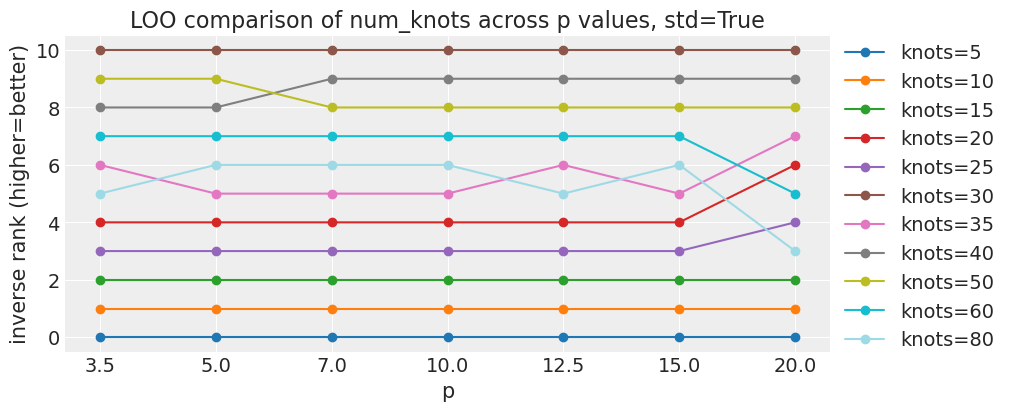

In [113]:
p_vals = [3.5, 5.0, 7.0, 10.0, 12.5, 15.0, 20.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80]

colors = cm.tab20(np.linspace(0, 1, len(num_knots_list)))
fig, ax = plt.subplots(figsize=(10, 4))

for nk, color in zip(num_knots_list, colors):
    ranks = []
    for p_val in p_vals:
        df = loo_compare(model_fits_folder, run_folders, p=[p_val], num_knots=None, std=[True])
        df['num_knots'] = df.index.str.extract(r'__knots\((\d+)', expand=False).astype(int)
        df['inv_rank'] = len(df) - 1 - np.array(range(len(df)))
        row = df[df['num_knots'] == nk]
        ranks.append(row['inv_rank'].values[0] if len(row) else np.nan)
    ax.plot(np.arange(len(p_vals)), ranks, marker='o', label=f'knots={nk}', color=color)

ax.set_title("LOO comparison of num_knots across p values, std=True")
ax.set_xlabel('p')
ax.set_ylabel('inverse rank (higher=better)')
ax.set_xticks(np.arange(len(p_vals)))
ax.set_xticklabels(p_vals)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.show()

---

In [ ]:
# Compare num_knots for different p values
p_vals = [0.1, 0.5, 1.0, 2.0, 3.5, 5.0, 7.0, 10.0]
fig, axes = plt.subplots(len(p_vals), 1, figsize=(8, 4 * len(p_vals)), sharex=False)

for ax, p_val in zip(axes, p_vals):
    df = loo_compare(model_fits_folder, run_folders, p=p_val, num_knots=None, std=False)
    df['num_knots'] = df.index.str.extract(r'__knots\((\d+)', expand=False).astype(int)
    df['rank'] = range(len(df))  # 0 = best
    df['inv_rank'] = len(df) - 1 - df['rank']  # higher = better

    id = np.argsort(df['num_knots'])
    ax.plot(df['num_knots'].iloc[id], df['inv_rank'].iloc[id], marker='o')
    ax.set_xticks(df['num_knots'].iloc[id])
    ax.set_xlabel('num_knots')
    ax.set_ylabel('inv_rank (higher=better)')
    ax.set_title(f'p={p_val}')

plt.show()